<a href="https://www.kaggle.com/code/paulomacedo22/summit-dupla-inteligencia-artificial2?scriptVersionId=350685409" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Classificação de tipos de vidro com SVM (Glass Identification Dataset)

Victor Gabriel Figueira Gonzaga RGM:11241100198
Paulo Vinicius Neves Macedo RGM:11241103437
 
Este notebook segue as etapas solicitadas:
 
1. Import do dataset para o Kaggle pessoal

2. Avaliação do banco de dados

3. Tratativa de dados ausentes

4. Tratativa de encoding, quando necessário
 

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
 


## 1. Import do dataset para o Kaggle pessoal
 
O dataset **Glass Classification** (`uciml/glass`), do repositório UCI, foi adicionado ao notebook pelo painel **Input** do Kaggle, ficando disponível na pasta `/kaggle/input`.
 
A célula abaixo é a célula padrão do ambiente Kaggle. Ela percorre a pasta `/kaggle/input` e lista os arquivos disponíveis, o que permite confirmar que o dataset foi importado corretamente e descobrir o caminho do arquivo `glass.csv`.

### 1.2 Leitura do arquivo CSV
 
Leitura do arquivo `glass.csv` com o `pd.read_csv()` e exibição das cinco primeiras linhas com `df.head()`. O dataset contém nove atributos numéricos (índice de refração `RI` e teores de `Na`, `Mg`, `Al`, `Si`, `K`, `Ca`, `Ba` e `Fe`) e a coluna `Type`, que representa o tipo de vidro e é a variável alvo da classificação.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/uciml/glass/glass.csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 2. Avaliação do banco de dados
 
### 2.1 Estrutura do dataset
 
Uso do `df.info()` para inspecionar a estrutura dos dados: quantidade de registros, nome das colunas, contagem de valores não nulos e tipo de cada coluna.
 
O conjunto possui 214 registros e 10 colunas, todas com 214 valores não nulos. Os nove atributos são do tipo `float64` e a variável alvo `Type` é do tipo `int64`.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


### 2.2 Estatísticas descritivas
 
Uso do `df.describe()` para obter média, desvio padrão, mínimo, quartis e máximo de cada coluna.
 
Observa-se que o silício (`Si`) é o componente predominante (média de 72,65), que o bário (`Ba`) está ausente em mais de 75% das amostras e que variáveis como `K` e `Ca` apresentam possíveis outliers. As escalas dos atributos são muito diferentes entre si, o que justifica a padronização dos dados antes do treinamento do SVM.

In [4]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


## 3. Tratativa de dados ausentes
 
### 3.1 Verificação de valores nulos e linhas duplicadas
 
A célula abaixo conta os valores nulos de cada coluna com `df.isnull().sum()` e as linhas duplicadas com `df.duplicated().sum()`. Caso exista algum valor ausente, o código preenche a coluna com a mediana, medida pouco sensível a outliers.
 
Resultado: nenhuma coluna possui valores ausentes, portanto nenhuma imputação foi necessária. Foi identificada 1 linha duplicada no conjunto.

In [5]:
# Tratativa de dados ausentes
print('Valores nulos por coluna:')
print(df.isnull().sum())

print('\nLinhas duplicadas:', df.duplicated().sum())

# Caso existam nulos (o Glass Dataset original geralmente não tem),
# tratamos com imputação pela mediana das colunas numéricas:
if df.isnull().sum().sum() > 0:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    print('Valores ausentes tratados com a mediana.')
else:
    print('Nenhum valor ausente encontrado no dataset.')

Valores nulos por coluna:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Linhas duplicadas: 1
Nenhum valor ausente encontrado no dataset.


## 4. Tratativa de encoding
 
Todos os atributos de entrada já são numéricos (`float64`), portanto não é necessário aplicar encoding nas variáveis preditoras.
 
A variável alvo `Type` também é numérica, mas suas classes não são sequenciais: existem os tipos 1, 2, 3, 5, 6 e 7, sem nenhuma amostra do tipo 4. Por isso foi aplicado o `LabelEncoder`, que converte as classes para uma sequência contínua de 0 a 5, armazenada na nova coluna `Type_encoded`. A célula também exibe a correspondência entre a classe original e a classe codificada.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

print('Classes originais -> classes codificadas:')
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f'  Type {original} -> {encoded}')

Classes originais -> classes codificadas:
  Type 1 -> 0
  Type 2 -> 1
  Type 3 -> 2
  Type 5 -> 3
  Type 6 -> 4
  Type 7 -> 5


## Complemento da etapa 2: análise visual do banco de dados
 
### 2.3 Distribuição das classes
 
Complemento da avaliação do banco de dados, agora de forma visual. O gráfico de barras mostra a quantidade de amostras de cada tipo de vidro e permite verificar se as classes estão desbalanceadas, o que influencia a interpretação das métricas do modelo.

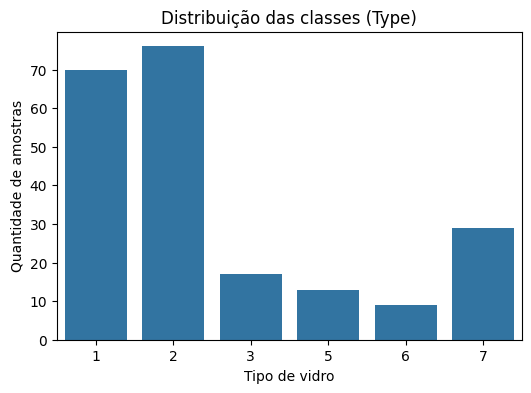

In [7]:
# Distribuição das classes (desbalanceamento é comum nesse dataset)
plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df, order=sorted(df['Type'].unique()))
plt.title('Distribuição das classes (Type)')
plt.xlabel('Tipo de vidro')
plt.ylabel('Quantidade de amostras')
plt.show()

### 2.4 Correlação entre os atributos
 
Mapa de calor com a correlação entre os nove atributos numéricos. As colunas `Type` e `Type_encoded` são retiradas do cálculo por representarem a classe. Valores próximos de 1 ou de -1 indicam forte relação linear entre dois atributos, e valores próximos de 0 indicam pouca relação.

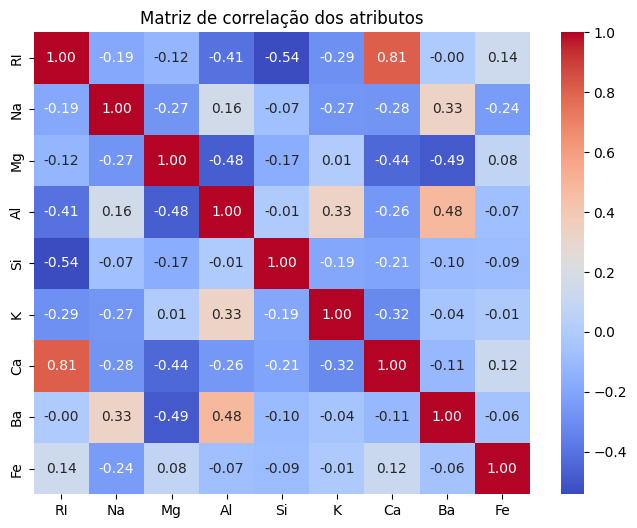

In [8]:
# Correlação entre os atributos numéricos
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=['Type', 'Type_encoded']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlação dos atributos')
plt.show()

## 5. Divisão dos dados de teste e treino
 
Separação do dataset em treino (80%) e teste (20%) usando `train_test_split`. O parâmetro `stratify=y` mantém a proporção de cada tipo de vidro nos dois conjuntos, o que é importante porque as classes estão desbalanceadas (visto no gráfico da seção 2.3).
 
As features (`X`) são as 9 colunas químicas originais; o alvo (`y`) é `Type_encoded`, já que o SVM trabalha melhor com classes numeradas de forma contínua.

In [9]:
from sklearn.model_selection import train_test_split
 
X = df.drop(columns=['Type', 'Type_encoded'])

y = df['Type_encoded']
 
X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42, stratify=y

)
 
print('Treino:', X_train.shape, ' Teste:', X_test.shape)
 

Treino: (171, 9)  Teste: (43, 9)


### 5.1 Padronização dos atributos
 
Como visto na seção 2.2, os atributos estão em escalas bem diferentes (ex.: `Si` na casa de 70, `Ba` perto de 0). O SVM é sensível a essa diferença de escala, então aplicamos o `StandardScaler`, ajustando-o apenas nos dados de treino (`fit_transform`) e reaplicando no teste (`transform`), para evitar vazamento de informação do teste para o treino.

In [10]:
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Aplicação do GridSearchCV e treino do modelo
 
Busca dos melhores hiperparâmetros do SVM (`C`, `gamma` e `kernel`) usando `GridSearchCV` com validação cruzada de 5 folds, testando qual combinação gera a maior acurácia média nos dados de treino.

In [11]:
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
 
param_grid = {

    'C': [0.1, 1, 10, 100],

    'gamma': ['scale', 'auto', 0.01, 0.1, 1],

    'kernel': ['rbf', 'linear', 'poly']

}
 
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid.fit(X_train_scaled, y_train)
 
print('Melhores hiperparâmetros:', grid.best_params_)

print('Melhor acurácia média (CV):', grid.best_score_)
 

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores hiperparâmetros: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Melhor acurácia média (CV): 0.6847058823529413


### 6.1 Treino do modelo final
 
Com os melhores hiperparâmetros encontrados, treinamos o modelo definitivo com os dados de treino já padronizados. Esse será o modelo avaliado na Etapa 3, com os dados de teste.
 

In [12]:
best_model = grid.best_estimator_

best_model.fit(X_train_scaled, y_train)
 

SVC(C=1, gamma=0.1)